<a href="https://colab.research.google.com/github/kalyani-m-g/weather-prediction-rnn/blob/main/weather_predictiom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from google.colab import files


In [27]:
# Upload dataset
uploaded = files.upload()
filename = list(uploaded.keys())[0]

Saving london_weather.csv to london_weather (2).csv


In [ ]:
df = pd.read_csv(filename)

In [ ]:
# Convert date
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [ ]:
# Select useful columns
features = [
    'mean_temp',
    'min_temp',
    'max_temp',
    'precipitation',
    'cloud_cover',
    'sunshine'
]

In [ ]:
df = df[features]

In [ ]:
# Fill missing values
df = df.fillna(method='ffill')

/tmp/ipykernel_5251/1282032457.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [ ]:
# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

In [ ]:
# ------------------------------------
# Create Sequences
# ------------------------------------
SEQ_LENGTH = 7

def create_sequences(data, seq_len):
    X, y = [], []

    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len][0])   # mean_temp

    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data, SEQ_LENGTH)

In [ ]:
# Train Test Split
train_size = int(len(X)*0.8)

X_train = X[:train_size]
X_test  = X[train_size:]

y_train = y[:train_size]
y_test  = y[train_size:]

In [ ]:
# Convert tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test  = torch.tensor(y_test, dtype=torch.float32)

In [ ]:
# ------------------------------------
# Dataset Class
# ------------------------------------
class WeatherDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_data = WeatherDataset(X_train, y_train)
test_data = WeatherDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)


In [ ]:
# ------------------------------------
# RNN Model
# ------------------------------------
class WeatherRNN(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size,1)

    def forward(self,x):
        h0 = torch.zeros(1, x.size(0), 64)
        out,_ = self.rnn(x,h0)
        out = self.fc(out[:,-1,:])
        return out.squeeze()

model = WeatherRNN(input_size=X_train.shape[2], hidden_size=64)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# ------------------------------------
# Train
# ------------------------------------
EPOCHS = 25
losses = []

for epoch in range(EPOCHS):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        output = model(X_batch)
        loss = criterion(output, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} Loss: {avg_loss:.4f}")

Epoch 1/25 Loss: 0.0085
Epoch 2/25 Loss: 0.0015
Epoch 3/25 Loss: 0.0011
Epoch 4/25 Loss: 0.0010
Epoch 5/25 Loss: 0.0009
Epoch 6/25 Loss: 0.0009
Epoch 7/25 Loss: 0.0009
Epoch 8/25 Loss: 0.0009
Epoch 9/25 Loss: 0.0009
Epoch 10/25 Loss: 0.0009
Epoch 11/25 Loss: 0.0009
Epoch 12/25 Loss: 0.0009
Epoch 13/25 Loss: 0.0009
Epoch 14/25 Loss: 0.0009
Epoch 15/25 Loss: 0.0009
Epoch 16/25 Loss: 0.0009
Epoch 17/25 Loss: 0.0009
Epoch 18/25 Loss: 0.0009
Epoch 19/25 Loss: 0.0009
Epoch 20/25 Loss: 0.0009
Epoch 21/25 Loss: 0.0009
Epoch 22/25 Loss: 0.0009
Epoch 23/25 Loss: 0.0009
Epoch 24/25 Loss: 0.0009
Epoch 25/25 Loss: 0.0009


In [ ]:
# ------------------------------------
# Evaluate
# ------------------------------------
model.eval()

predictions = []
actuals = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        predictions.extend(output.numpy())
        actuals.extend(y_batch.numpy())

mse = mean_squared_error(actuals, predictions)
mae = mean_absolute_error(actuals, predictions)

print("\nMean Squared Error:", mse)
print("Mean Absolute Error:", mae)


Mean Squared Error: 0.0010430831693106143
Mean Absolute Error: 0.024363605586740843


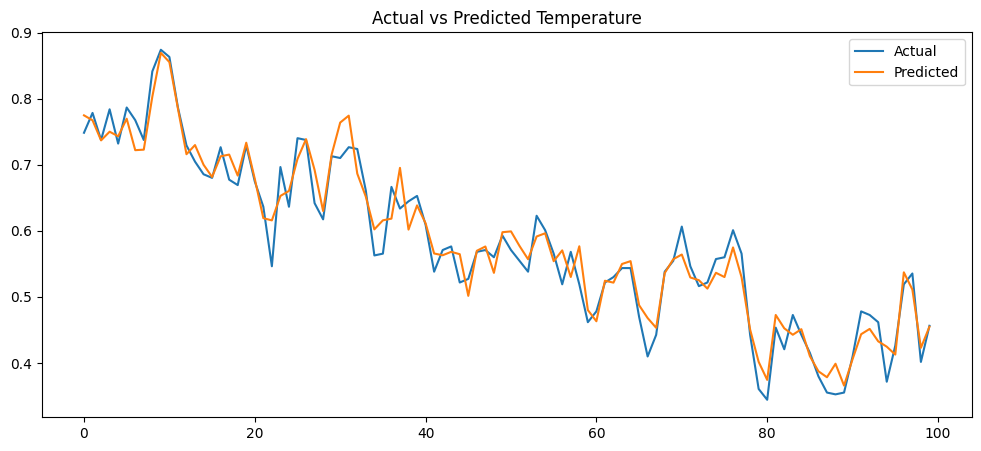

In [ ]:
# ------------------------------------
# Plot Predictions
# ------------------------------------
plt.figure(figsize=(12,5))
plt.plot(actuals[:100], label="Actual")
plt.plot(predictions[:100], label="Predicted")
plt.title("Actual vs Predicted Temperature")
plt.legend()
plt.show()

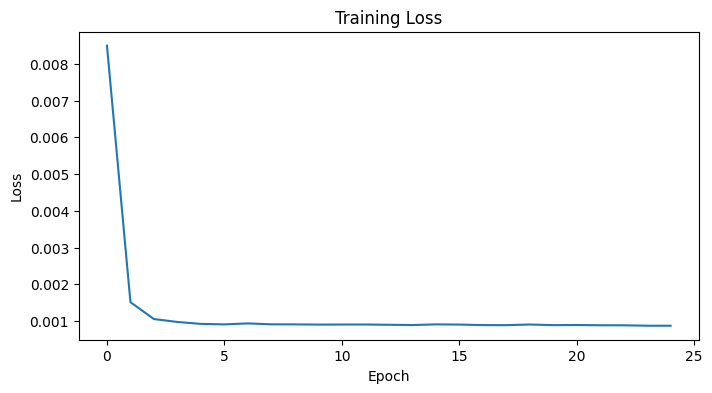

In [ ]:
# ------------------------------------
# Loss Curve
# ------------------------------------
plt.figure(figsize=(8,4))
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [ ]:
# ------------------------------------
# Predict Next Day
# ------------------------------------
last_seq = X_test[-1].unsqueeze(0)

with torch.no_grad():
    pred = model(last_seq).item()

temp_arr = np.zeros((1,6))
temp_arr[0,0] = pred

next_day_temp = scaler.inverse_transform(temp_arr)[0,0]

print("Predicted Next Day Mean Temperature:", next_day_temp)

Predicted Next Day Mean Temperature: 3.2674574851989755
